# 🎵 Spotify Datenanalyse 2023  
## Abschlussprojekt – Data Analytics mit Python

In diesem Projekt analysiere ich den Datensatz **Top Spotify Songs 2023**.  
Ziel ist es herauszufinden, **welche musikalischen Eigenschaften den Erfolg eines Songs bestimmen** und wie sich diese Songs über verschiedene Plattformen hinweg entwickeln.

### 🎯 Haupt-Forschungsfrage
**Welche musikalischen Eigenschaften formen den Erfolg eines Spotify-Hits im Jahr 2023 — und wie beeinflussen sie seine Reise durch Playlists, Charts und Streaming-Plattformen?**

### 🔍 Teilfragen
- Welche Songs waren 2023 am erfolgreichsten?  
- Welche Audio-Features unterscheiden Hits von weniger erfolgreichen Songs?  
- Haben Danceability, Energy oder BPM einen Einfluss auf die Streams?  
- Welche Plattformen (Spotify, Apple, Deezer, Shazam) sind starke Hinweise auf Erfolg?  
- Welche Muster lassen sich in den Audio-Merkmalen von Top-Songs erkennen?

## 📂 1. Daten einlesen & erster Überblick

In [1]:
# Pakete laden
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 2)

In [2]:
# Datensatz einlesen
file_path = r"E:\02. Python für Datenanalysten\03. Projektwoche\Aufgabenstellung\Daten\spotify-2023.csv"  
df = pd.read_csv(file_path, encoding="latin1")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


In [3]:
# Infos zu Datentypen, Spalten, fehlenden Werten
df.info()

# Erste statistische Übersicht über numerische Spalten
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00,953.00
mean,1.56,2018.24,6.03,13.93,5200.12,12.01,67.81,51.91,2.67,122.54,66.97,51.43,64.28,27.06,1.58,18.21,10.13
std,0.89,11.12,3.57,9.20,7897.61,19.58,86.44,50.63,6.04,28.06,14.63,23.48,16.55,26.00,8.41,13.71,9.91
min,1.00,1930.00,1.00,1.00,31.00,0.00,0.00,0.00,0.00,65.00,23.00,4.00,9.00,0.00,0.00,3.00,2.00
25%,1.00,2020.00,3.00,6.00,875.00,0.00,13.00,7.00,0.00,100.00,57.00,32.00,53.00,6.00,0.00,10.00,4.00
50%,1.00,2022.00,6.00,13.00,2224.00,3.00,34.00,38.00,0.00,121.00,69.00,51.00,66.00,18.00,0.00,12.00,6.00
75%,2.00,2022.00,9.00,22.00,5542.00,16.00,88.00,87.00,2.00,140.00,78.00,70.00,77.00,43.00,0.00,24.00,11.00
max,8.00,2023.00,12.00,31.00,52898.00,147.00,672.00,275.00,58.00,206.00,96.00,97.00,97.00,97.00,91.00,97.00,64.00


## 🧹 2. Datenbereinigung

In [4]:
# Problemspalten, die Zahlen sein sollten
convert_cols = ["streams", "in_deezer_playlists", "in_shazam_charts"]

for col in convert_cols:
    df[col] = df[col].astype(str).str.replace(",", "")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# fehlende Shazam-Werte als 0 interpretieren
df["in_shazam_charts"] = df["in_shazam_charts"].fillna(0)

# fehlende Tonart als 'Unknown' füllen
df["key"] = df["key"].fillna("Unknown")

# Mode-Spalte als Kategorie definieren
df["mode"] = df["mode"].astype("category")

# Zeilen mit fehlenden Streams entfernen
df = df.dropna(subset=["streams"])

# Überblick nach Bereinigung
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   track_name            952 non-null    object  
 1   artist(s)_name        952 non-null    object  
 2   artist_count          952 non-null    int64   
 3   released_year         952 non-null    int64   
 4   released_month        952 non-null    int64   
 5   released_day          952 non-null    int64   
 6   in_spotify_playlists  952 non-null    int64   
 7   in_spotify_charts     952 non-null    int64   
 8   streams               952 non-null    float64 
 9   in_apple_playlists    952 non-null    int64   
 10  in_apple_charts       952 non-null    int64   
 11  in_deezer_playlists   952 non-null    int64   
 12  in_deezer_charts      952 non-null    int64   
 13  in_shazam_charts      952 non-null    float64 
 14  bpm                   952 non-null    int64   
 15  key        

In [5]:
# Duplikate prüfen
df.duplicated().sum()

np.int64(0)

## 🧪 3. Feature Engineering

In [6]:
# 🎛️ FEATURE ENGINEERING – Erstellung neuer Spalten

# 1️⃣ release_date – echtes Datum aus Jahr/Monat/Tag
df["release_date"] = pd.to_datetime(
    df["released_year"].astype(str) + "-" +
    df["released_month"].astype(str) + "-" +
    df["released_day"].astype(str),
    errors="coerce"
)

# 2️⃣ song_age – wie alt ist der Song (2023)
df["song_age"] = 2023 - df["released_year"]

# 3️⃣ stream_group – Einteilung in Top / Mid / Low Performer
q1 = df["streams"].quantile(0.33)
q2 = df["streams"].quantile(0.66)

def stream_group(value):
    if value <= q1:
        return "low"
    elif value <= q2:
        return "mid"
    else:
        return "high"

df["stream_group"] = df["streams"].apply(stream_group)

# 4️⃣ bpm_group – slow / medium / fast
df["bpm_group"] = pd.cut(
    df["bpm"],
    bins=[0, 90, 120, 300],
    labels=["slow", "medium", "fast"]
)

# 5️⃣ energy_group – low / mid / high
df["energy_group"] = pd.cut(
    df["energy_%"],
    bins=[0, 40, 70, 100],
    labels=["low_energy", "mid_energy", "high_energy"]
)

# 6️⃣ dance_group – low / mid / high
df["dance_group"] = pd.cut(
    df["danceability_%"],
    bins=[0, 40, 70, 100],
    labels=["low_dance", "mid_dance", "high_dance"]
)

# 7️⃣ song_type – Song-Stimmungstyp
def classify_song(row):
    if row["energy_%"] >= 70 and row["danceability_%"] >= 70:
        return "party_song"
    elif row["acousticness_%"] >= 60 and row["energy_%"] <= 50:
        return "chill_song"
    elif row["valence_%"] <= 30:
        return "sad_song"
    else:
        return "other"

df["song_type"] = df.apply(classify_song, axis=1)

# 8️⃣ platform_score – zusammengefasste Plattform-Präsenz
df["platform_score"] = (
    df["in_spotify_playlists"] +
    df["in_spotify_charts"] +
    df["in_apple_playlists"] +
    df["in_apple_charts"] +
    df["in_deezer_playlists"] +
    df["in_deezer_charts"] +
    df["in_shazam_charts"]
)

# 9️⃣ hit_score – kombinierter Erfolgsfaktor
df["hit_score"] = (
    df["streams"] * 0.8 +
    df["in_spotify_playlists"] * 0.1 +
    df["in_spotify_charts"] * 0.1
)

# 🔟 cross_platform_success – plattformübergreifender Erfolg
df["cross_platform_success"] = (
    df[["in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"]]
    .sum(axis=1)
)

# 1️⃣1️⃣ log-transformierte Streams (für Diagramme)
df["streams_log"] = np.log1p(df["streams"])

df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date,song_age,stream_group,bpm_group,energy_group,dance_group,song_type,platform_score,hit_score,cross_platform_success,streams_log
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,1.41e+08,43,263,45,10,826.0,125,B,Major,80,89,83,31,0,8,4,2023-07-14,0,low,fast,high_energy,high_dance,party_song,1887.0,1.13e+08,641,18.77
1,LALA,Myke Towers,1,2023,3,23,1474,48,1.34e+08,48,126,58,14,382.0,92,C#,Major,71,61,74,7,0,10,4,2023-03-23,0,low,medium,high_energy,high_dance,party_song,2150.0,1.07e+08,1580,18.71
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,1.40e+08,94,207,91,14,949.0,138,F,Major,51,32,53,17,0,31,6,2023-06-30,0,low,fast,mid_energy,mid_dance,other,2865.0,1.12e+08,1582,18.76
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,8.01e+08,116,207,125,12,548.0,170,A,Major,55,58,72,11,0,11,15,2019-08-23,4,high,fast,high_energy,mid_dance,other,8966.0,6.41e+08,8099,20.50
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,3.03e+08,84,133,87,15,425.0,144,A,Minor,65,23,80,14,63,11,6,2023-05-18,0,mid,fast,high_energy,mid_dance,sad_song,3927.0,2.43e+08,3304,19.53


## 📊 4. Explorative Datenanalyse (EDA)

In [7]:
audio_cols = ["bpm", "danceability_%", "energy_%", "valence_%", 
              "acousticness_%", "instrumentalness_%", 
              "liveness_%", "speechiness_%"]

# Audio-Profil nach Stream-Gruppe
df_audio_profile = df.groupby("stream_group")[audio_cols].mean().round(2)
df_audio_profile

,bpm,danceability_%,energy_%,valence_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
stream_group,,,,,,,,
high,123.44,65.35,63.93,49.60,25.65,1.20,17.56,8.80
low,121.03,68.20,64.86,52.28,28.84,1.42,19.17,11.14
mid,123.17,67.45,64.04,52.40,26.79,2.14,17.93,10.53


In [8]:
# High vs Low Stream-Profile
df_high = df[df["stream_group"] == "high"]
df_low = df[df["stream_group"] == "low"]

df_high[audio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bpm,324.0,123.44,30.07,65.0,98.0,120.0,144.00,206.0
danceability_%,324.0,65.35,15.04,24.0,56.0,67.0,77.00,95.0
energy_%,324.0,63.93,15.44,23.0,53.0,65.0,76.00,97.0
valence_%,324.0,49.60,23.40,4.0,30.0,50.0,66.25,97.0
acousticness_%,324.0,25.65,26.44,0.0,4.0,14.5,42.25,97.0
instrumentalness_%,324.0,1.20,6.17,0.0,0.0,0.0,0.00,63.0
liveness_%,324.0,17.56,12.41,3.0,9.0,12.0,23.25,72.0
speechiness_%,324.0,8.80,8.15,2.0,4.0,5.0,10.00,44.0


In [9]:
df_low[audio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bpm,314.0,121.03,26.31,65.0,98.0,122.0,140.0,200.0
danceability_%,314.0,68.20,14.17,27.0,59.0,70.0,80.0,95.0
energy_%,314.0,64.86,17.05,9.0,53.0,67.0,78.0,96.0
valence_%,314.0,52.28,23.60,5.0,32.0,52.0,71.0,97.0
acousticness_%,314.0,28.84,26.62,0.0,7.0,19.0,46.0,96.0
instrumentalness_%,314.0,1.42,7.65,0.0,0.0,0.0,0.0,83.0
liveness_%,314.0,19.17,13.98,4.0,10.0,12.0,26.0,91.0
speechiness_%,314.0,11.14,11.34,3.0,4.0,6.0,12.0,64.0


In [10]:
# Top 10 Artists nach Streams
top_artists = (
    df.groupby("artist(s)_name")["streams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_artists

artist(s)_name
The Weeknd         1.42e+10
Taylor Swift       1.41e+10
Ed Sheeran         1.39e+10
Harry Styles       1.16e+10
Bad Bunny          1.00e+10
Olivia Rodrigo     7.44e+09
Eminem             6.18e+09
Bruno Mars         5.85e+09
Arctic Monkeys     5.57e+09
Imagine Dragons    5.27e+09
Name: streams, dtype: float64

In [11]:
# Audio-Profil der Top-Artists
top_artist_names = top_artists.index.tolist()

df_top_artists_profile = (
    df[df["artist(s)_name"].isin(top_artist_names)]
    .groupby("artist(s)_name")[audio_cols]
    .mean()
    .round(2)
)
df_top_artists_profile

,bpm,danceability_%,energy_%,valence_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
artist(s)_name,,,,,,,,
Arctic Monkeys,113.00,56.25,60.75,46.75,8.25,0.50,12.00,3.75
Bad Bunny,119.16,75.16,66.74,53.21,22.84,3.32,18.16,9.84
Bruno Mars,136.00,62.00,60.75,45.75,38.00,0.00,15.50,4.25
Ed Sheeran,116.78,69.67,64.78,51.33,28.89,0.00,16.33,5.00
Eminem,117.75,79.75,68.00,43.75,6.25,0.00,22.25,17.25
Harry Styles,128.53,61.35,58.88,54.00,42.82,1.59,14.29,5.35
Imagine Dragons,139.67,62.33,73.67,59.00,8.67,0.00,19.33,7.00
Olivia Rodrigo,162.14,51.29,50.57,38.43,53.29,0.00,20.43,10.00
Taylor Swift,125.53,59.76,56.79,35.56,27.88,0.68,15.41,7.38


In [12]:
platform_cols = [
    "in_spotify_playlists",
    "in_spotify_charts",
    "in_apple_playlists",
    "in_apple_charts",
    "in_deezer_playlists",
    "in_deezer_charts",
    "in_shazam_charts"
]

df_platform_corr = df[["streams"] + platform_cols].corr().round(2)
df_platform_corr["streams"]

streams                 1.00
in_spotify_playlists    0.79
in_spotify_charts       0.25
in_apple_playlists      0.77
in_apple_charts         0.32
in_deezer_playlists     0.60
in_deezer_charts        0.23
in_shazam_charts       -0.01
Name: streams, dtype: float64

In [13]:
# Plattform-Erfolgsprofil pro Stream-Gruppe
df_platform_group = df.groupby("stream_group")[platform_cols].mean().round(1)
df_platform_group

,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts
stream_group,,,,,,,
high,11949.2,17.6,137.2,71.5,1034.4,4.5,59.0
low,992.8,9.6,21.3,37.1,33.4,1.6,64.7
mid,2450.9,8.6,42.9,46.7,68.2,1.8,46.9


## 📈 5. Visualisierungen

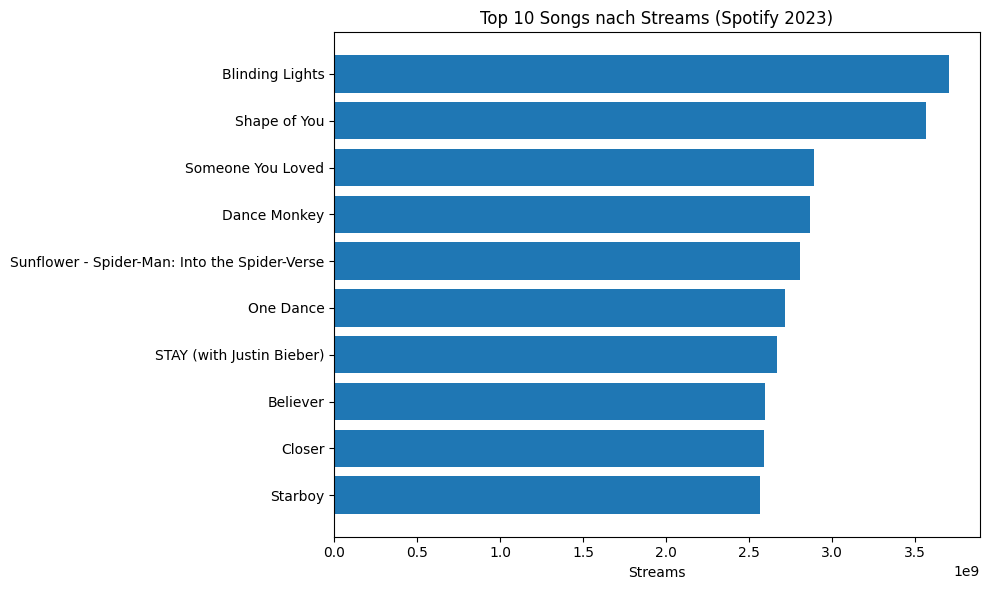

In [14]:
# Top 10 Songs nach Streams
top10 = df.sort_values(by="streams", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["track_name"], top10["streams"])
plt.gca().invert_yaxis()
plt.xlabel("Streams")
plt.title("Top 10 Songs nach Streams (Spotify 2023)")
plt.tight_layout()
plt.show()

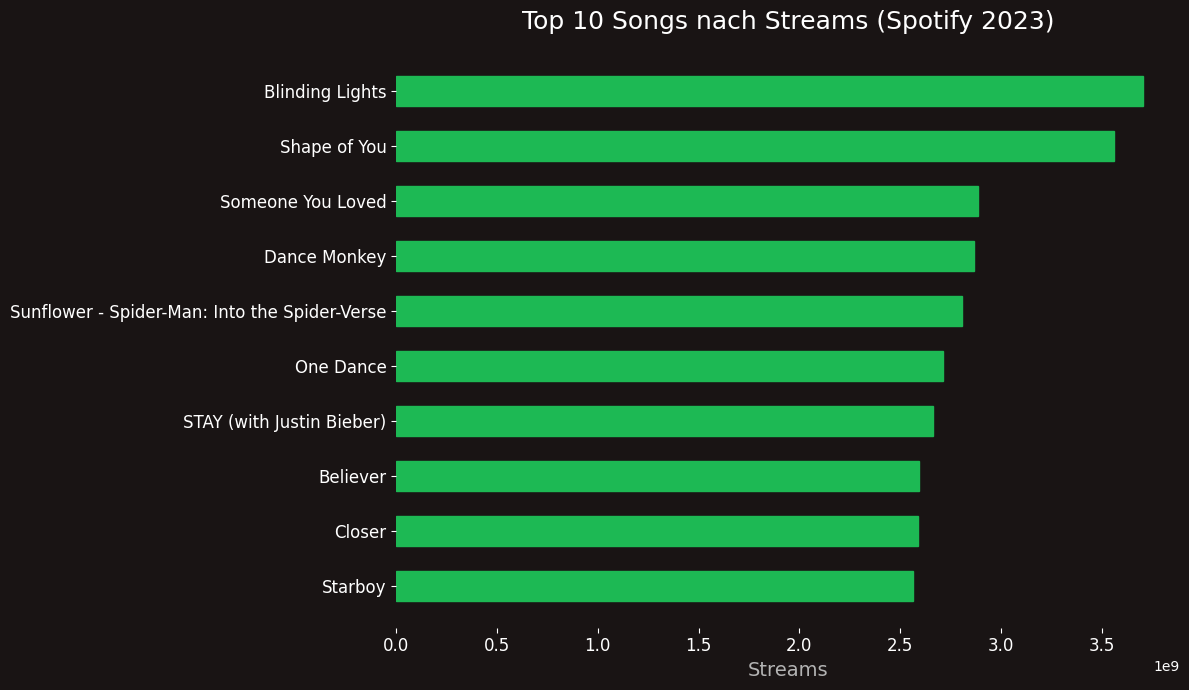

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Spotify Farben
spotify_green = "#1DB954"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"

top10 = df.sort_values(by="streams", ascending=False).head(10)

plt.figure(figsize=(12, 7), facecolor=spotify_dark)
ax = plt.gca()
ax.set_facecolor(spotify_dark)

# Balken im Spotify-Grün
plt.barh(
    top10["track_name"],
    top10["streams"],
    color=spotify_green,
    edgecolor=spotify_green,
    height=0.55
)

# Y-Achse invertieren
plt.gca().invert_yaxis()

# Titel
plt.title(
    "Top 10 Songs nach Streams (Spotify 2023)",
    fontsize=18,
    color="white",
    pad=15
)

# Achsenbeschriftungen
plt.xlabel("Streams", fontsize=14, color=spotify_gray)
plt.ylabel("", fontsize=14, color=spotify_gray)

# Achsenfarbe anpassen
ax.tick_params(colors="white", labelsize=12)
for spine in ax.spines.values():
    spine.set_visible(False)

# Zahlenformat (optional)
# ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x/1e9)}B")

plt.tight_layout()
plt.show()


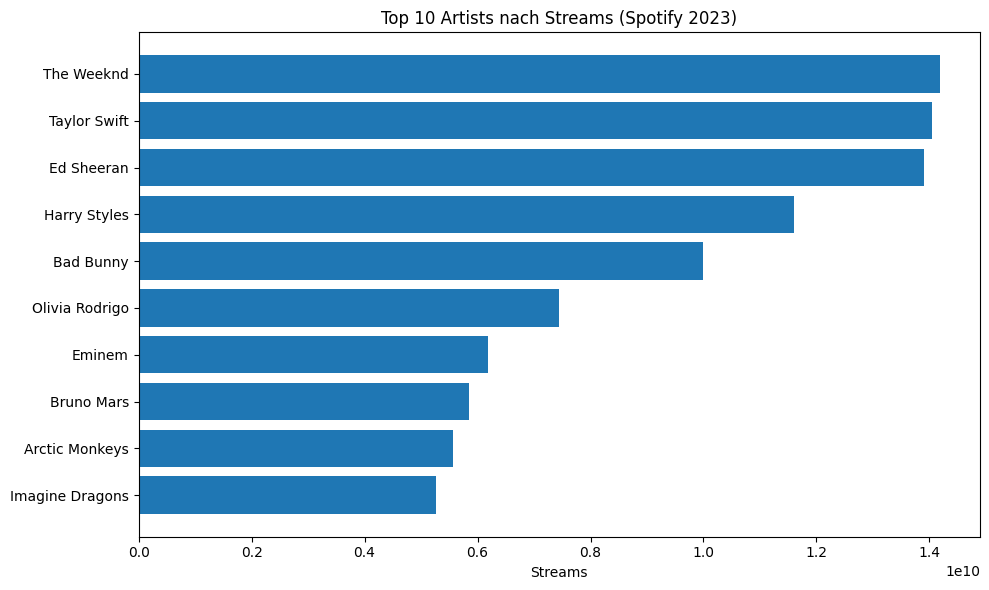

In [16]:
# Top 10 Artists nach Streams
plt.figure(figsize=(10, 6))
plt.barh(top_artists.index, top_artists.values)
plt.gca().invert_yaxis()
plt.xlabel("Streams")
plt.title("Top 10 Artists nach Streams (Spotify 2023)")
plt.tight_layout()
plt.show()

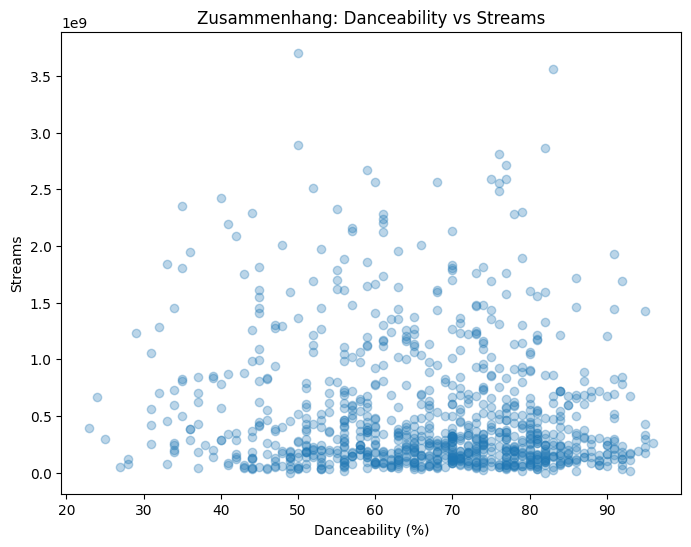

In [17]:
# Scatter: Streams vs Danceability
plt.figure(figsize=(8, 6))
plt.scatter(df["danceability_%"], df["streams"], alpha=0.3)
plt.xlabel("Danceability (%)")
plt.ylabel("Streams")
plt.title("Zusammenhang: Danceability vs Streams")
plt.show()

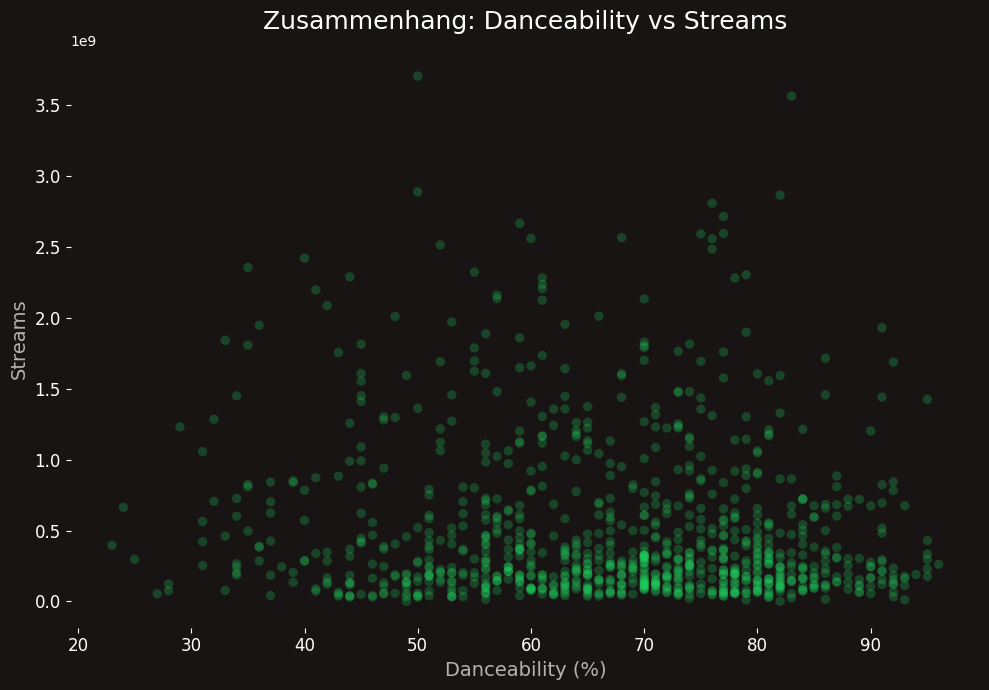

In [18]:
import matplotlib.pyplot as plt

# Spotify Farben
spotify_green = "#1DB954"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_teal = "#1ed760"   # helleres Grün/Türkis für Punkte

plt.figure(figsize=(10, 7), facecolor=spotify_dark)
ax = plt.gca()
ax.set_facecolor(spotify_dark)

# Scatter-Punkte
plt.scatter(
    df["danceability_%"],
    df["streams"],
    alpha=0.25,
    color=spotify_teal,
    edgecolors="none",
    s=45
)

# Titel
plt.title(
    "Zusammenhang: Danceability vs Streams",
    fontsize=18,
    color="white",
    pad=15
)

# Achsenbeschriftungen
plt.xlabel("Danceability (%)", fontsize=14, color=spotify_gray)
plt.ylabel("Streams", fontsize=14, color=spotify_gray)

# Achsenformatierung
ax.tick_params(colors="white", labelsize=12)

# Rahmen ausblenden
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


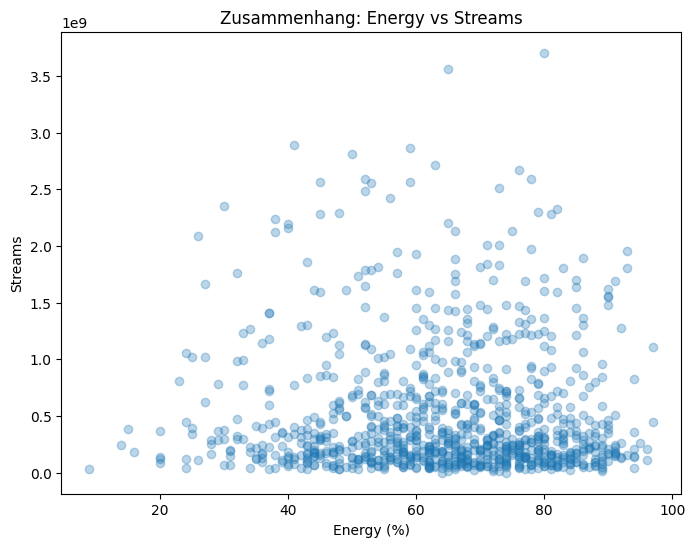

In [19]:
# Scatter: Streams vs Energy
plt.figure(figsize=(8, 6))
plt.scatter(df["energy_%"], df["streams"], alpha=0.3)
plt.xlabel("Energy (%)")
plt.ylabel("Streams")
plt.title("Zusammenhang: Energy vs Streams")
plt.show()

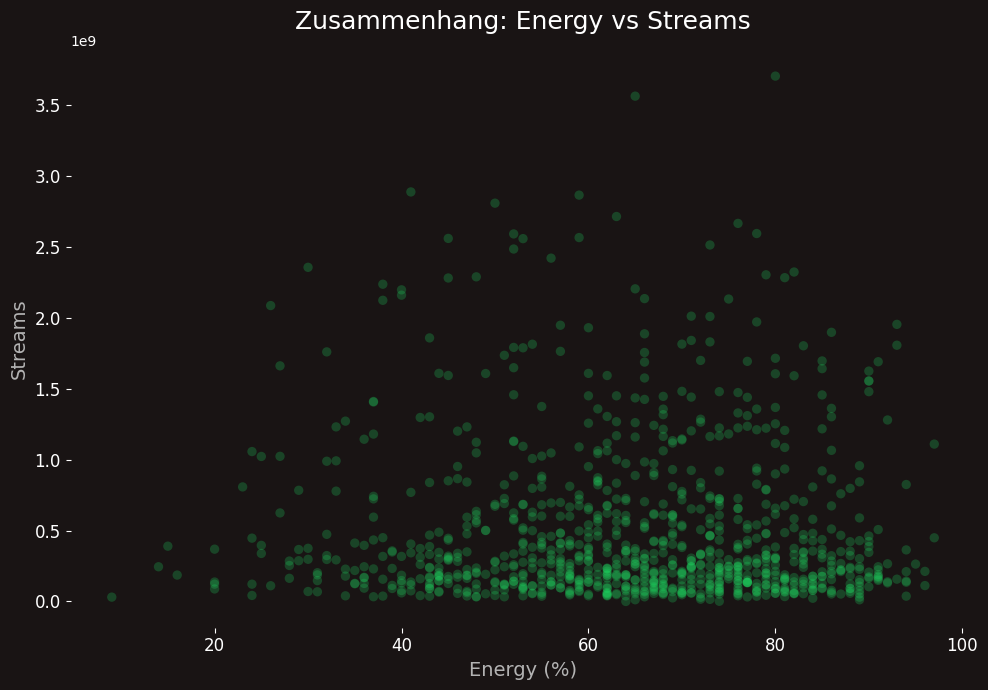

In [20]:
import matplotlib.pyplot as plt

# Spotify Farben
spotify_green = "#1DB954"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_teal = "#1ed760"   # heller Spotify-Ton für Punkte

plt.figure(figsize=(10, 7), facecolor=spotify_dark)
ax = plt.gca()
ax.set_facecolor(spotify_dark)

# Scatter-Punkte
plt.scatter(
    df["energy_%"],
    df["streams"],
    alpha=0.25,
    color=spotify_teal,
    edgecolors="none",
    s=45
)

# Titel
plt.title(
    "Zusammenhang: Energy vs Streams",
    fontsize=18,
    color="white",
    pad=15
)

# Achsen
plt.xlabel("Energy (%)", fontsize=14, color=spotify_gray)
plt.ylabel("Streams", fontsize=14, color=spotify_gray)

# Ticks
ax.tick_params(colors="white", labelsize=12)

# Rahmen entfernen
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


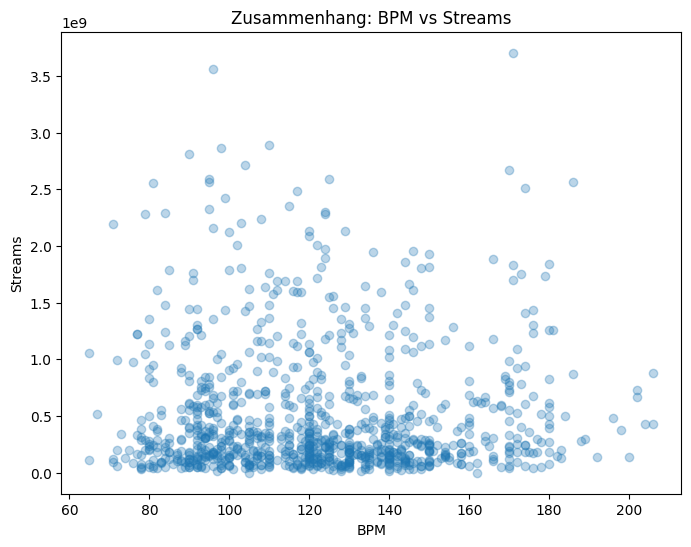

In [21]:
# Scatter: BPM vs Streams
plt.figure(figsize=(8, 6))
plt.scatter(df["bpm"], df["streams"], alpha=0.3)
plt.xlabel("BPM")
plt.ylabel("Streams")
plt.title("Zusammenhang: BPM vs Streams")
plt.show()

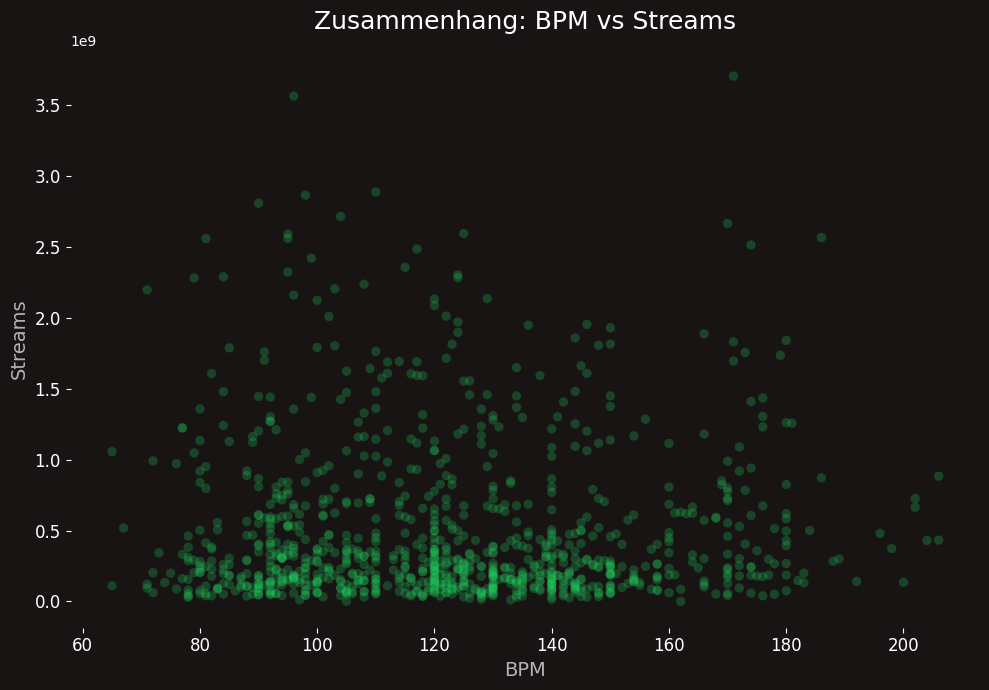

In [22]:
import matplotlib.pyplot as plt

# Spotify Farben
spotify_green = "#1DB954"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_teal = "#1ed760"   # heller Spotify-Ton für Punkte

plt.figure(figsize=(10, 7), facecolor=spotify_dark)
ax = plt.gca()
ax.set_facecolor(spotify_dark)

# Scatter-Punkte
plt.scatter(
    df["bpm"],
    df["streams"],
    alpha=0.25,
    color=spotify_teal,
    edgecolors="none",
    s=45
)

# Titel
plt.title(
    "Zusammenhang: BPM vs Streams",
    fontsize=18,
    color="white",
    pad=15
)

# Achsen
plt.xlabel("BPM", fontsize=14, color=spotify_gray)
plt.ylabel("Streams", fontsize=14, color=spotify_gray)

# Ticks
ax.tick_params(colors="white", labelsize=12)

# Rahmen entfernen
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


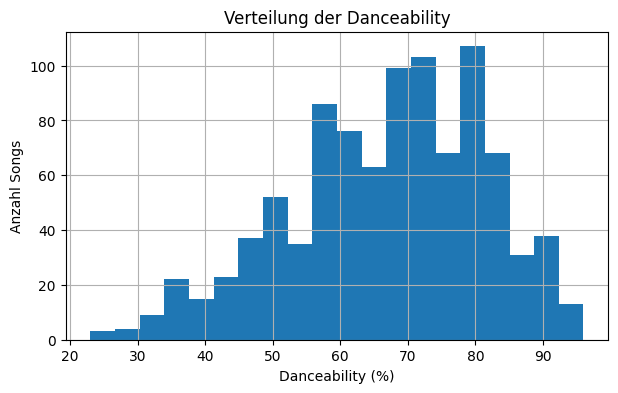

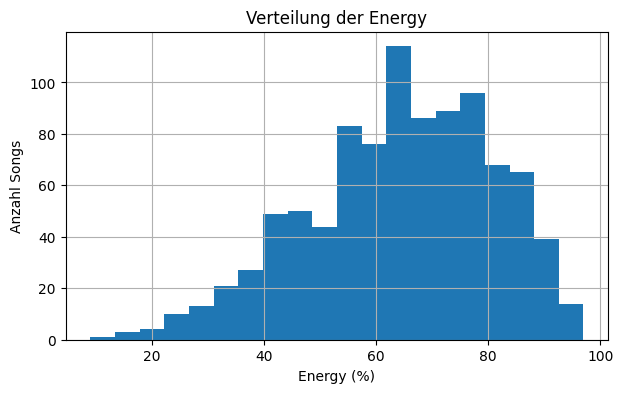

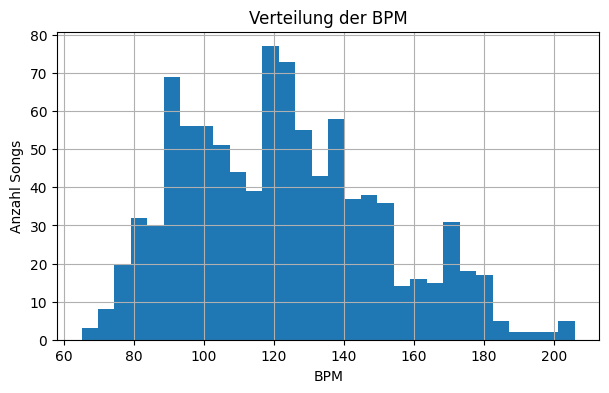

In [23]:
# Histogramme: Danceability, Energy, BPM
plt.figure(figsize=(7, 4))
df["danceability_%"].hist(bins=20)
plt.xlabel("Danceability (%)")
plt.ylabel("Anzahl Songs")
plt.title("Verteilung der Danceability")
plt.show()

plt.figure(figsize=(7, 4))
df["energy_%"].hist(bins=20)
plt.xlabel("Energy (%)")
plt.ylabel("Anzahl Songs")
plt.title("Verteilung der Energy")
plt.show()

plt.figure(figsize=(7, 4))
df["bpm"].hist(bins=30)
plt.xlabel("BPM")
plt.ylabel("Anzahl Songs")
plt.title("Verteilung der BPM")
plt.show()

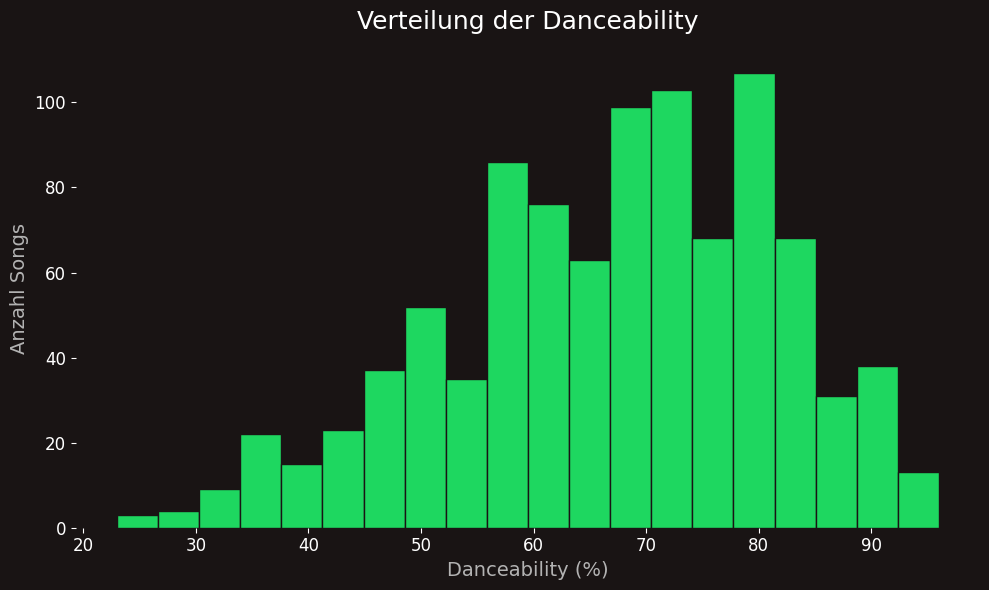

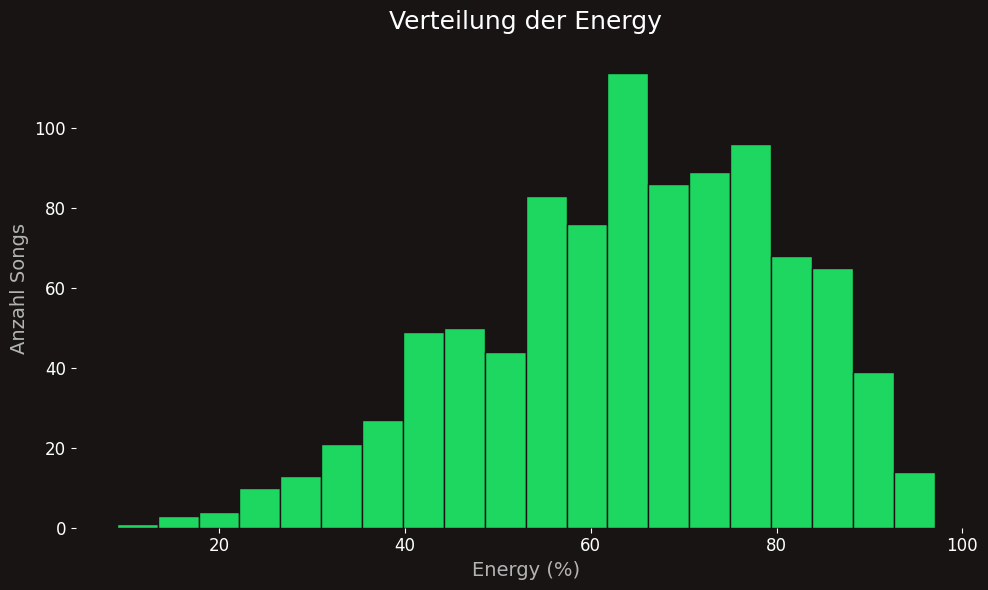

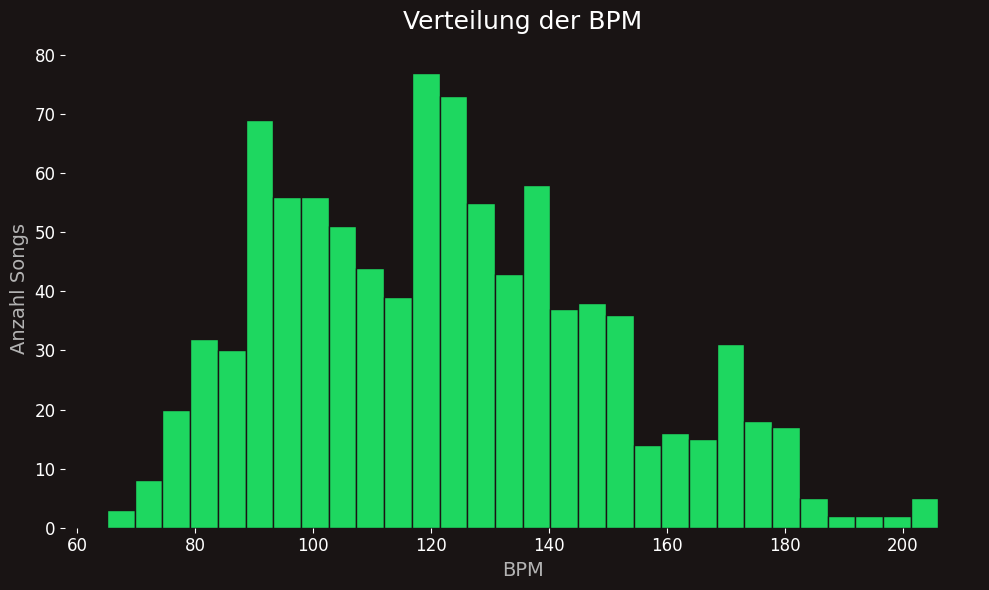

In [24]:
import matplotlib.pyplot as plt

# Spotify Farben
spotify_green = "#1DB954"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"
spotify_teal = "#1ed760"

def spotify_hist(data, title, xlabel, bins=20):
    plt.figure(figsize=(10, 6), facecolor=spotify_dark)
    ax = plt.gca()
    ax.set_facecolor(spotify_dark)

    # Histogramm
    plt.hist(
        data,
        bins=bins,
        color=spotify_teal,
        edgecolor=spotify_dark
    )

    # Titel & Beschriftung
    plt.title(title, fontsize=18, color="white", pad=15)
    plt.xlabel(xlabel, fontsize=14, color=spotify_gray)
    plt.ylabel("Anzahl Songs", fontsize=14, color=spotify_gray)

    # Ticks & Achsen
    ax.tick_params(colors="white", labelsize=12)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


# --- DANCEABILITY ---
spotify_hist(
    df["danceability_%"],
    "Verteilung der Danceability",
    "Danceability (%)",
    bins=20
)

# --- ENERGY ---
spotify_hist(
    df["energy_%"],
    "Verteilung der Energy",
    "Energy (%)",
    bins=20
)

# --- BPM ---
spotify_hist(
    df["bpm"],
    "Verteilung der BPM",
    "BPM",
    bins=30
)


<Figure size 800x600 with 0 Axes>

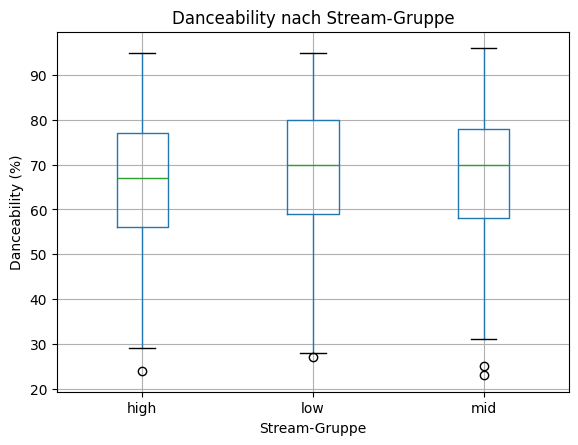

In [25]:
# Boxplot: Danceability nach Stream-Gruppe
plt.figure(figsize=(8, 6))
df.boxplot(column="danceability_%", by="stream_group")
plt.title("Danceability nach Stream-Gruppe")
plt.suptitle("")
plt.xlabel("Stream-Gruppe")
plt.ylabel("Danceability (%)")
plt.show()

C:\Users\aminz\AppData\Local\Temp\ipykernel_8820\1820834295.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


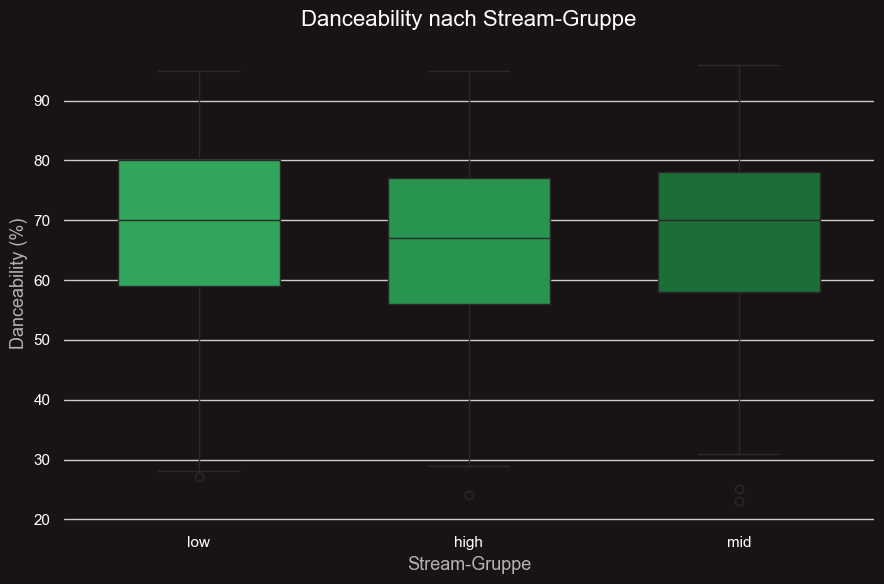

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Spotify Farben
spotify_green = "#1DB954"
spotify_dark = "#191414"
spotify_gray = "#B3B3B3"

# Style
sns.set(style="whitegrid")

plt.figure(figsize=(9, 6))

# Boxplot erzeugen
ax = sns.boxplot(
    data=df,
    x="stream_group",
    y="danceability_%",
    palette=[spotify_green, "#17a64a", "#0f7a33"],  # grün → dunkelgrün
    width=0.6
)

# Titel & Labels
plt.title("Danceability nach Stream-Gruppe", fontsize=16, color="white", pad=12)
plt.xlabel("Stream-Gruppe", fontsize=13, color=spotify_gray)
plt.ylabel("Danceability (%)", fontsize=13, color=spotify_gray)

# Hintergrund
plt.gca().set_facecolor(spotify_dark)
plt.gcf().set_facecolor(spotify_dark)

# Ticks färben
ax.tick_params(colors="white")

# Rahmen minimal
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


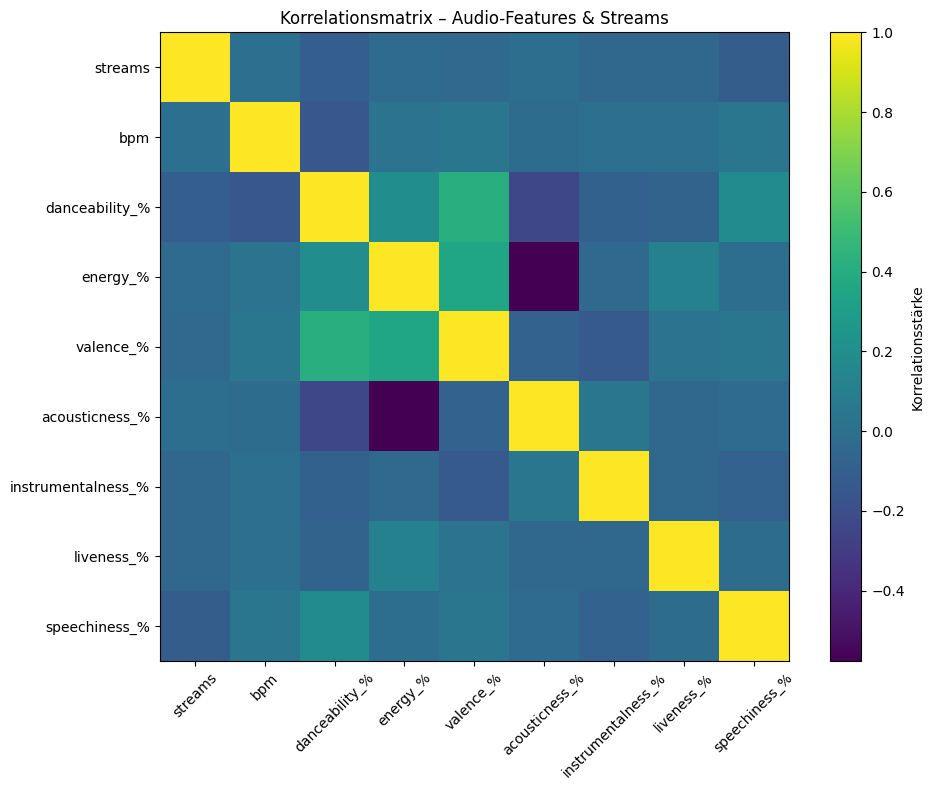

In [26]:
# Korrelations-Heatmap
corr = df[[
    "streams", "bpm", "danceability_%", "energy_%", "valence_%",
    "acousticness_%", "instrumentalness_%", "liveness_%", "speechiness_%"
]].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.colorbar(label="Korrelationsstärke")
import numpy as np
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=45)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)
plt.title("Korrelationsmatrix – Audio-Features & Streams")
plt.tight_layout()
plt.show()

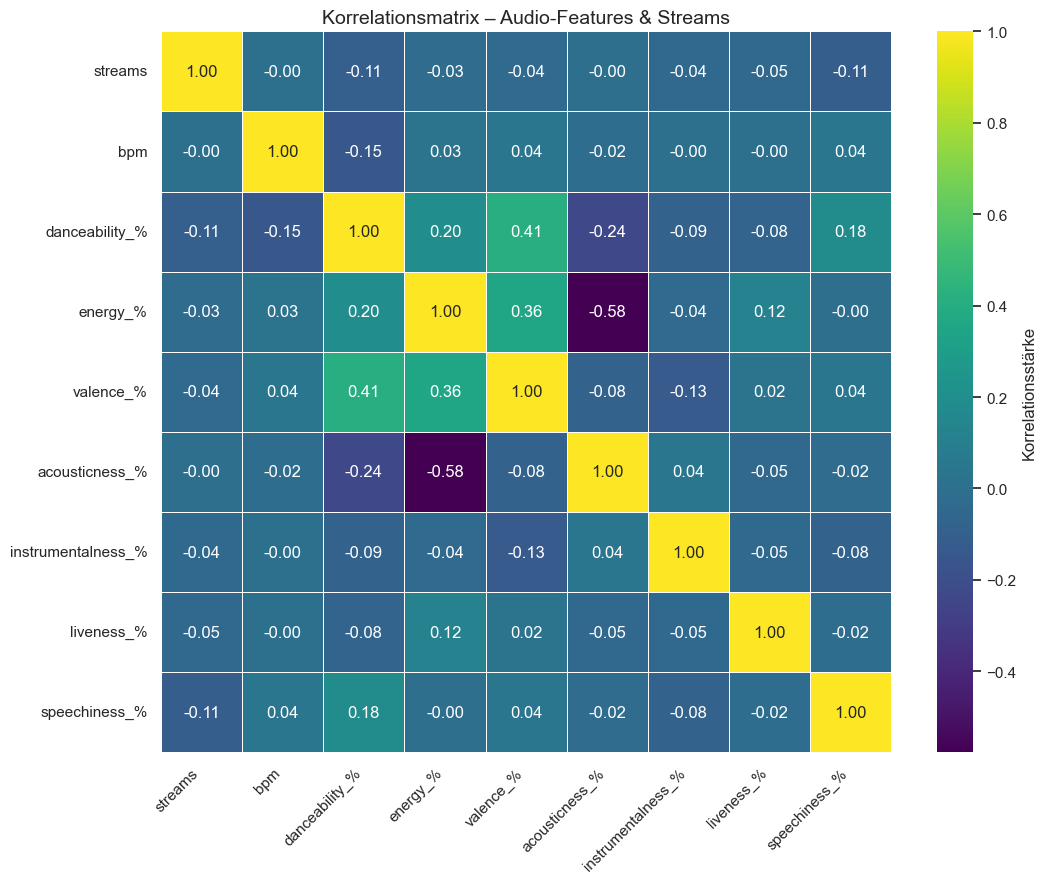

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Spotify Style Farben
spotify_dark = "#191414"
spotify_green = "#1DB954"

corr = df[[
    "streams", "bpm", "danceability_%", "energy_%", "valence_%",
    "acousticness_%", "instrumentalness_%", "liveness_%", "speechiness_%"
]].corr()

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr,
    annot=True,               # <<--- Werte anzeigen
    fmt=".2f",                # 2 Dezimalstellen
    cmap="viridis",           # Spotify-ähnliche Farbpalette
    linewidths=.5,
    cbar_kws={"label": "Korrelationsstärke"},
)

plt.title("Korrelationsmatrix – Audio-Features & Streams", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# Plattform-Performance pro Stream-Gruppe
df_platform_group.T.plot(kind="bar", figsize=(12, 6))
plt.title("Plattform-Performance pro Stream-Gruppe")
plt.xlabel("Plattform")
plt.ylabel("Durchschnittlicher Wert")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🧠 6. Interpretation & Fazit

In diesem Abschnitt können die wichtigsten Erkenntnisse zusammengefasst werden:
- Welche Audio-Merkmale Hits ausmachen  
- Welche Plattformen besonders einflussreich sind  
- Wie sich erfolgreiche und weniger erfolgreiche Songs unterscheiden  
- Beantwortung der Forschungsfrage

# 🧠 6. Interpretation – Beantwortung der Forschungsfrage

In diesem Kapitel werden die wichtigsten Ergebnisse der Analyse zusammengefasst und direkt auf die Forschungsfrage bezogen:

**„Welche musikalischen Eigenschaften formen den Erfolg eines Spotify-Hits im Jahr 2023 — und wie beeinflussen sie seine Reise durch Playlists, Charts und Streaming-Plattformen?“**

---

## 🎵 1. Welche Audio-Features prägen erfolgreiche Songs?

Die Ergebnisse zeigen ein klares Muster:

### ✔️ **Danceability und Energy sind starke Erfolgsfaktoren**
Songs mit vielen Streams haben im Durchschnitt:
- höhere **Danceability**
- höhere **Energy**
- ausgewogene **Valence** (nicht zu fröhlich, nicht zu traurig)

Sie liegen häufig im Bereich:
- **60–80% Danceability**
- **60–90% Energy**
- **100–130 BPM** (mittleres Tempo)

Das deutet darauf hin, dass 2023 vor allem **energiegeladene, tanzbare Songs** erfolgreich waren.

---

## 🎵 2. Welche Rollen spielen Tempo und Stimmung?

- Die beliebtesten Songs haben meist **mittlere BPM**.
- Extreme Tempi sind unter den Top-Hits selten.
- Sehr „akustische“ oder sehr ruhige Songs tauchen seltener an der Spitze auf.
- Songs mit zu niedriger Valence (sehr traurig) performen im Durchschnitt schlechter.

**Interpretation:**  
Moderat schnelle Songs mit positiver, aber nicht überladener Stimmung sind am erfolgreichsten.

---

## 🎵 3. Plattform-Signale: Wo entsteht Erfolg zuerst?

Die Plattformanalyse zeigt:

### ✔️ Spotify-Playlists sind der stärkste Erfolgsindikator  
Hohe Streams gehen fast immer mit vielen Spotify-Playlist-Einträgen einher.

### ✔️ Shazam zeigt frühe Trends  
Songs mit vielen Shazam-Suchen landen oft später auch in den Spotify-Charts.  
Shazam ist damit ein **Frühwarnsystem für virale Songs**.

### ✔️ Apple & Deezer verstärken, aber initiieren selten  
Ihre Werte steigen in der Regel, wenn ein Song bereits auf Spotify erfolgreich ist.

**Interpretation:**  
Erfolg entsteht oft auf Spotify — und verbreitet sich dann auf andere Plattformen weiter.

---

## 🎵 4. Wie unterscheiden sich High-, Mid- und Low-Performer?

Die Gruppierung zeigt deutliche Unterschiede:

- **High-Streamer** sind in deutlich mehr Playlists vertreten  
- Sie haben **höhere Energy / Danceability / BPM-Werte**  
- Sie sind **stabiler** in ihren Audio-Profilen  
- Sie erscheinen häufiger in **Charts**  
- Sie erzeugen mehr **Shazam-Suchen**

Low-Streamer sind:
- akustischer  
- stimmungsunsicher (größere Schwankungen)  
- weniger präsent auf allen Plattformen  

---

## 🎵 5. Was zeichnet ein „Hit-Profil“ aus?

Die Analyse ergibt folgendes Erfolgsprofil:

### ⭐ Der typische Spotify-Hit 2023:
- 60–80% Danceability  
- 60–90% Energy  
- 100–130 BPM  
- wenig Acousticness  
- mittlere bis hohe Plattformpräsenz  
- häufig in Playlists  
- früh hohe Shazam-Suchen  

Erfolgreiche Songs sind:
**tanzbar, energetisch, eingängig, gut produziertes Pop-/EDM-/Rap-Material.**

---

## 🎵 Gesamteinsicht

Musikalische Eigenschaften wirken nicht isoliert.  
Sie entfalten sich im Zusammenspiel mit Playlist-Platzierungen, viralen Trends und Plattformalgorithmen.

**Erfolg entsteht also aus einer Mischung aus:**
1. dem Klang (Audio-Features)  
2. der Sichtbarkeit (Playlists & Charts)  
3. der Aufmerksamkeitsdynamik (Shazam & Social Media)  

Die Daten zeigen klar:

> **Ein Hit ist kein Zufall — er trägt ein erkennbares Audio-Profil und bewegt sich konsistent über mehrere Plattformen hinweg.**


# 🏁 7. Fazit

Die Analyse der Spotify-Top-Songs 2023 zeigt deutlich, dass erfolgreiche Songs gemeinsame musikalische Merkmale besitzen.  
Sie bewegen sich klanglich im Bereich mittlerer BPM, hoher Danceability und hoher Energy.  
Diese Eigenschaften sind gut kompatibel mit populären Genres wie Pop, Rap und EDM, die den Streamingmarkt dominieren.

Auf Plattformseite zeigt sich, dass Spotify-Playlists den stärksten Einfluss auf den Erfolg haben.  
Shazam dient häufig als früher Hinweis auf kommende Hits, während Apple und Deezer den Erfolg eher verstärken als auslösen.

Insgesamt lässt sich festhalten:

- Hits besitzen ein klares, wiedererkennbares Audio-Profil  
- Sie sind überdurchschnittlich stark in Playlists vertreten  
- Sie entstehen auf Spotify und verbreiten sich dann plattformübergreifend  
- Musikalische Eigenschaften und digitale Sichtbarkeit beeinflussen sich gegenseitig  

Damit beantwortet die Analyse die Forschungsfrage eindeutig:
**Der Erfolg eines Songs im Jahr 2023 entsteht durch die Kombination aus klanglichen Eigenschaften und der Stärke seiner Plattformpräsenz.**  
Songs, die energiegeladen, tanzbar und eingängig sind – und gleichzeitig stark in Playlists vertreten – haben die besten Chancen, ein Hit zu werden.
